# Лабораторная работа: Проверка статистических гипотез о нормальности распределения, расчет мощности и критерии согласия

**Цель работы:** 
1. Научиться применять графические методы (KDE, Q-Q Plots) и строгие статистические критерии (Шапиро–Уилка, Д’Агостино-Пирсона) для проверки выборок на нормальность в среде Python.
2. Эмпирически исследовать зависимость мощности тестов от объема выборки («парадокс больших выборок») методом Монте-Карло.
3. Освоить алгоритм ручной группировки данных и применения критерия согласия $\chi^2$ Пирсона с процедурой объединения малочисленных интервалов.

**Используемый стек:** Python 3.x, NumPy, SciPy (scipy.stats), Matplotlib, Seaborn, Pandas, tqdm.

---

## Часть 1. Теоретический минимум

При проверке данных на нормальность формулируются следующие гипотезы:
*   **$H_0$ (Нулевая гипотеза):** Исследуемая случайная величина распределена нормально.
*   **$H_1$ (Альтернативная гипотеза):** Распределение исследуемой случайной величины существенно отличается от нормального.

**Правило принятия решения по $p$-value:**
*   Если $p\text{-value} > \alpha$ (обычно $\alpha = 0.05$), то у нас **нет оснований отвергать $H_0$**. Мы условно считаем данные нормальными.
*   Если $p\text{-value} \le \alpha$, то мы **отвергаем $H_0$** в пользу альтернативной гипотезы. Данные НЕ нормальны.

---

## Часть 2. Инициализация и выбор варианта

Укажите ваш индивидуальный номер варианта в ячейке ниже для генерации уникальных наборов данных.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# УКАЖИТЕ СВОЙ НОМЕР ВАРИАНТА НИЖЕ:
MY_VARIANT = 1

print(f"Активирован вариант №{MY_VARIANT}. Данные готовы к генерации!")

Активирован вариант №1. Данные готовы к генерации!


---
## Часть 3. Практические задания

### 📉 Задание 1. Теоретическое и визуальное сравнение плотностей
**Задача:** Математически и графически проверить утверждение: *«При числе степеней свободы df = 20 распределение Стьюдента (t-распределение) визуально почти неотличимо от стандартного нормального распределения»*.

**Инструкция:**
1. Изучите и запустите код ниже.
2. Зафиксируйте значение максимальной абсолютной разницы между плотностями.

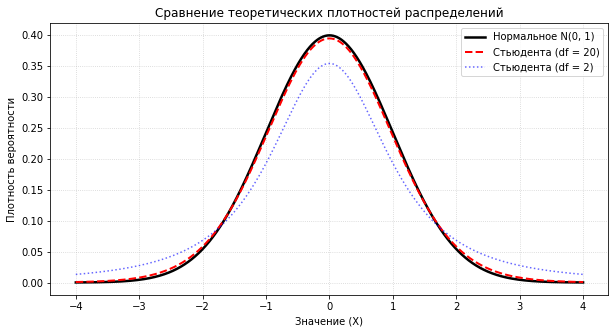

Максимальная разница по Фишеру между N(0,1) и t(df=20): 0.00670


In [2]:
x = np.linspace(-4, 4, 1000)

pdf_norm = stats.norm.pdf(x, loc=0, scale=1)
pdf_t_20 = stats.t.pdf(x, df=20)
pdf_t_2  = stats.t.pdf(x, df=2)

plt.figure(figsize=(10, 5))
plt.plot(x, pdf_norm, label='Нормальное N(0, 1)', color='black', linewidth=2.5)
plt.plot(x, pdf_t_20, label='Стьюдента (df = 20)', color='red', linestyle='--', linewidth=2)
plt.plot(x, pdf_t_2, label='Стьюдента (df = 2)', color='blue', linestyle=':', alpha=0.6)

plt.title('Сравнение теоретических плотностей распределений')
plt.xlabel('Значение (X)')
plt.ylabel('Плотность вероятности')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

max_diff = np.max(np.abs(pdf_norm - pdf_t_20))
print(f"Максимальная разница по Фишеру между N(0,1) и t(df=20): {max_diff:.5f}")

### 📊 Задание 2. Эксперимент с объемом выборки («Парадокс больших выборок»)
**Задача:** Исследовать, как объем выборки ($n$) влияет на результаты тестов Шапиро–Уилка и Д’Агостино-Пирсона при извлечении данных из распределения Стьюдента ($df=20$).

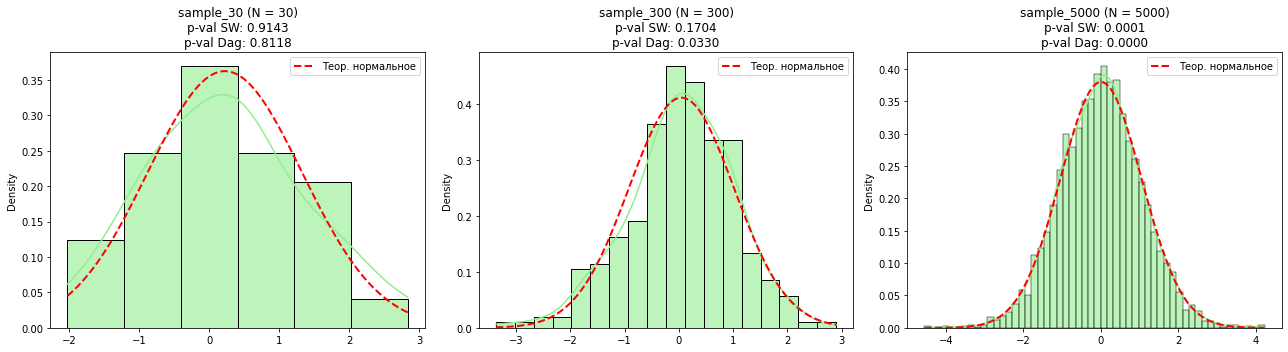

    Выборка  Размер (N)  p-value (Шапиро-Уилок)  p-value (Д'Агостино)
  sample_30          30                 0.91427               0.81185
 sample_300         300                 0.17044               0.03297
sample_5000        5000                 0.00007               0.00001


In [3]:
np.random.seed(MY_VARIANT)
df_student = 20

samples = {
    'sample_30': stats.t.rvs(df=df_student, size=30),
    'sample_300': stats.t.rvs(df=df_student, size=300),
    'sample_5000': stats.t.rvs(df=df_student, size=5000)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results = []

for i, (name, data) in enumerate(samples.items()):
    N = len(data)
    stat_sw, p_sw = stats.shapiro(data)
    stat_dag, p_dag = stats.normaltest(data)
    
    results.append({
        'Выборка': name,
        'Размер (N)': N,
        'p-value (Шапиро-Уилок)': round(p_sw, 5),
        'p-value (Д\'Агостино)': round(p_dag, 5)
    })
    
    sns.histplot(data, kde=True, stat="density", color="lightgreen", ax=axes[i], alpha=0.6)
    x_plot = np.linspace(data.min(), data.max(), 100)
    axes[i].plot(x_plot, stats.norm.pdf(x_plot, loc=data.mean(), scale=data.std()), 
                 color='red', linestyle='--', linewidth=2, label='Теор. нормальное')
    
    axes[i].set_title(f'{name} (N = {N})\np-val SW: {p_sw:.4f}\np-val Dag: {p_dag:.4f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

### 🚀 Задание 3 (Повышенная сложность). Расчет мощности критерия методом Монте-Карло
**Задача:** Эмпирически оценить мощность критерия Шапиро–Уилка для объемов выборок $n = 30$, $n = 300$ и $n = 5000$ при генерации данных из распределения Стьюдента ($df=20$).

**Инструкция:**
1. Допишите код симуляции Монте-Карло для каждого объема выборки.
2. Проведите $10\,000$ симуляций для каждого $n$, фиксируя долю случаев, когда полученный $p\text{-value} \le 0.05$.

### 📊 Задание 4. Критерий согласия $\chi^2$ Пирсона и группировка данных
**Задача:** Проверить гипотезу о нормальности выборки `sample_5000` с помощью критерия Хи-квадрат Пирсона, самостоятельно построив интервальный ряд и объединив малочисленные интервалы ($E_i < 5$).

**Инструкция:**
1. Разбейте выборку на интервалы.
2. Рассчитайте наблюдаемые частоты ($O_i$) и теоретические частоты ($E_i$) через `stats.norm.cdf`.
3. Реализуйте алгоритм слияния интервалов, где $E_i < 5$.
4. Запустите `stats.chisquare` с аргументом `ddof=2`.

---
## Часть 4. Контрольные вопросы

Ответьте на вопросы письменно в отчете:
1. **Анализ расхождения (Задание 1):** Какое максимальное расхождение плотностей получилось между $N(0,1)$ и $t(df=20)$? Сильно ли меняется график при $df=2$?
2. **«Глаз» против математики (Задание 2):** Изменилась ли внутренняя природа данных при увеличении выборки с $n=30$ до $n=5000$? Как вы объясните противоречие между графиком плотности («идеальный колокол») и ответом тестов ($p < 0.05$)?
3. **Анализ мощности (Задание 3):** Назовите полученные значения эмпирической мощности для $n=30$ и $n=5000$. Какую ошибку (I или II рода) совершает тест Шапиро–Уилка на малых выборках в данном эксперименте?
4. **Инструкция для аналитика:** База клиентов содержит 10 000 строк. График распределения — идеальный симметричный «колокол», но тест Шапиро-Уилка выдает p-value = 0.00001. Можно ли по этой выборке из 10000 наблюдений построить доверительные интервалы для математического ожидания или дисперсии?
5. **Хи-квадрат особенности (Задание 4):** Зачем в алгоритме выполняется слияние малочисленных интервалов? Почему в функции chisquare необходимо указывать именно параметр ddof=2? Как влияет на мощность критерия Хи-квадрат наличие малочисленных интервалов и неверное задание числа степеней свободы статистики критерия?

In [ ]:
### ОТЧЕТ